# Visual Localization

Given a 3D scene reconstructed by the feedforward pipeline, this notebook finds the camera pose of a held-out query image within the scene. The pipeline runs three stages: global frame retrieval via DINOv2-SALAD descriptors, local feature matching with XFeat, and absolute pose estimation via PnP+RANSAC (pycolmap).

In [1]:
%load_ext autoreload
%autoreload 2

## §1 — Load reconstruction

Load the precomputed `FeedforwardResult` from the zarr cache. The reconstruction holds 3D point positions, per-frame camera extrinsics and intrinsics, and the source image paths.

In [ ]:
import os
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pyvista as pv
import torch
%matplotlib inline

from collab_splats.pointcloud.feedforward.base import FeedforwardResult
from collab_splats.localization import CameraLocalizer, XFeatExtractor, plot_correspondences
from collab_splats.utils.visualization import create_camera_frustum_pyvista, pointcloud_to_polydata

# Use trame for interactive 3D rendering in the notebook
pv.set_jupyter_backend("trame")

In [3]:
%run ../tutorial_config.py

# ── Configuration ─────────────────────────────────────────────────────────────
METHOD  = "vggtx"

RECON     = CACHE_DIR / METHOD / "feedforward.zarr"

assert RECON.exists(), (
    f"feedforward.zarr not found at {RECON}. Run 02_pointcloud/feedforward_methods first."
)
print(f"RECON: {RECON}")

RECON: /workspace/outputs/birds_c0043/vggtx/feedforward.zarr


In [4]:
# Load the pre-built reconstruction from the zarr cache
result = FeedforwardResult.load_zarr(RECON)
print(f"points: {result.points.shape}  frames: {result.extrinsics.shape[0]}")

points: (500000, 3)  frames: 30


## §2 — Hold out query frame

Select one frame as the query image and build a trimmed scene containing all remaining frames. The query's ground-truth extrinsic is retained for a consistency check at the end.

In [5]:
QUERY_IDX = 10

# Load query image (BGR → RGB) and its intrinsics from the reconstruction
query_bgr = cv2.imread(str(result.image_paths[QUERY_IDX]))
query_image = query_bgr[..., ::-1].copy()
query_K = result.intrinsics[QUERY_IDX]
ref_extrinsic = result.extrinsics[QUERY_IDX]  # kept for error check at §5

# Build trimmed scene — all frames except the query
keep = [i for i in range(len(result.image_paths)) if i != QUERY_IDX]

class _Trimmed:
    """Minimal scene container matching the FeedforwardResult interface."""
    points = result.points          # shared — 3D points are not frame-specific
    extrinsics = result.extrinsics[keep]
    intrinsics = result.intrinsics[keep]
    image_paths = [result.image_paths[i] for i in keep]

result_trimmed = _Trimmed()
print(f"Scene: {len(result_trimmed.image_paths)} reference frames, query held out at index {QUERY_IDX}")

Scene: 29 reference frames, query held out at index 10


## §3 — Localize query image

`CameraLocalizer.from_feedforward` indexes the reference frames. `localize` runs global retrieval → XFeat matching → PnP+RANSAC and returns a `LocalizationResult` with the estimated world-to-camera pose.

> **Note:** Index build reads and extracts local features for every reference frame. Expect ~30 s for 20 frames, several minutes for 100+ frames — one-time cost per scene. (Future: cache features in feedforward.zarr.)

In [6]:
# Build localizer — indexes reference descriptors once
localizer = CameraLocalizer.from_feedforward(result_trimmed, extractor=XFeatExtractor())

# Run localization: retrieval → feature matching → PnP+RANSAC
loc = localizer.localize(query_image, query_K)
print(f"correspondences: {loc.n_correspondences}  inliers: {loc.n_inliers}  pose: {'found' if loc.pose is not None else 'FAILED'}")
if loc.pose is None:
    raise RuntimeError("Localization failed — check n_correspondences above. Try a different QUERY_IDX.")

loading weights from: /workspace/collab-splats/third_party/xfeat/modules/../weights/xfeat.pt


/workspace/collab-splats/third_party/xfeat/modules/xfeat.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.net.load_state_dict(torch.load(weights, map_location=self.

Indexing frames:   0%|          | 0/29 [00:00<?, ?frame/s]

Loaded LightGlue model


/workspace/collab-splats/third_party/xfeat/modules/lighterglue.py:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weights, map_location=self.dev)


correspondences: 355  inliers: 88  pose: found


## §4 — Correspondences

Visualize the 2D keypoint matches between the query image and the top retrieved reference frame. Inlier matches (green) survive RANSAC; outliers (red) are rejected.

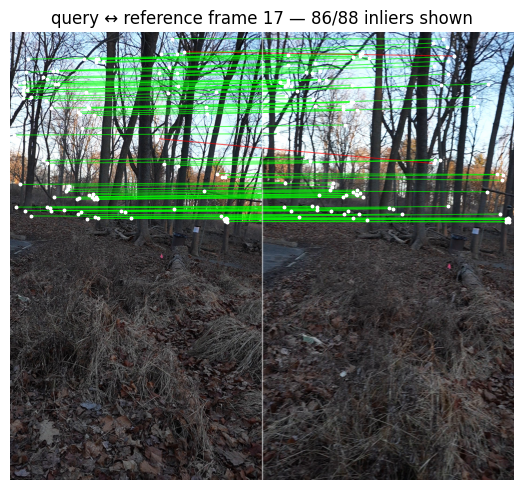

In [7]:
plot_correspondences(loc, query_image, result_trimmed.image_paths)

## §5 — 3D scene view

Render the reference camera frustums (grey) and the estimated query pose (red) in 3D. The query frustum should be visually consistent with the nearby reference frames.

In [8]:
# Add point cloud and reference camera frustums
pl = pv.Plotter()
pl.add_mesh(pointcloud_to_polydata(result_trimmed.points), point_size=2, render_points_as_spheres=True)
for ext in result_trimmed.extrinsics:
    pl.add_mesh(create_camera_frustum_pyvista(np.linalg.inv(ext), scale=0.05), color="grey", line_width=1)

# Add localized query pose in red
pl.add_mesh(create_camera_frustum_pyvista(np.linalg.inv(loc.pose), scale=0.05), color="red", line_width=3)
pl.add_axes()
pl.show()

2026-07-08 20:52:57.159 (  50.689s) [    7414C17B8740]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


Widget(value='<iframe src="http://localhost:32917/index.html?ui=P_0x740f180632d0_0&reconnect=auto" class="pyvi…

## §6 — Error metrics

Compute rotation and translation error against the feedforward reference extrinsic. This is a consistency check — the feedforward pose is not absolute ground truth but serves as a sanity bound.

In [9]:
# Compute geodesic rotation error and Euclidean translation error
R_est = loc.pose[:3, :3]
R_ref  = ref_extrinsic[:3, :3]
rot_err_deg = np.degrees(np.arccos(np.clip((np.trace(R_est @ R_ref.T) - 1) / 2, -1, 1)))
t_err_cm = np.linalg.norm(loc.pose[:3, 3] - ref_extrinsic[:3, 3]) * 100

print(f"vs feedforward reference — rotation: {rot_err_deg:.2f}°  |  translation: {t_err_cm:.1f} cm")
print("(consistency check vs feedforward model — not absolute ground truth)")

vs feedforward reference — rotation: 3.40°  |  translation: 10.9 cm
(consistency check vs feedforward model — not absolute ground truth)


## §7 — LoMa matcher

[LoMa](https://github.com/davnords/LoMa) (ECCV 2026) is a sparse keypoint
matcher — DaD detector + DINOv2 descriptors + a LightGlue-style transformer
matcher — that substantially outperforms LightGlue pipelines on WxBS/IMC22.
It is registered as `"loma"` (LoMa-B) and `"loma-g"` (LoMa-G, best accuracy).
Weights auto-download on first use (~723 MB / ~1.4 GB).

In [ ]:
from collab_splats.localization import LomaExtractor

# Build a second localizer with the LoMa-B extractor and localize the same query
localizer_loma = CameraLocalizer.from_feedforward(result_trimmed, extractor=LomaExtractor())
res_loma = localizer_loma.localize(query_image, query_K)
print(f"LoMa-B: {res_loma.n_inliers}/{res_loma.n_correspondences} inliers")

In [11]:
# Compare both matchers on the same query
pd.DataFrame(
    [
        ("XFeat", loc.n_correspondences, loc.n_inliers),
        ("LoMa-B", res_loma.n_correspondences, res_loma.n_inliers),
    ],
    columns=["matcher", "correspondences", "RANSAC inliers"],
)

,matcher,correspondences,RANSAC inliers
0,XFeat,355,88
1,LoMa-B,2373,585


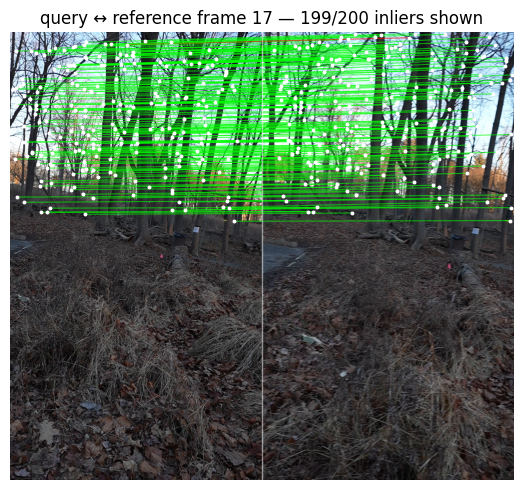

In [12]:
# Visualize LoMa matches the same way as §4
plot_correspondences(res_loma, query_image, result_trimmed.image_paths)

In [13]:
# Same consistency check as §6, for the LoMa pose
R_est_loma = res_loma.pose[:3, :3]
rot_err_loma_deg = np.degrees(np.arccos(np.clip((np.trace(R_est_loma @ R_ref.T) - 1) / 2, -1, 1)))
t_err_loma_cm = np.linalg.norm(res_loma.pose[:3, 3] - ref_extrinsic[:3, 3]) * 100

print(f"LoMa-B vs feedforward reference — rotation: {rot_err_loma_deg:.2f}°  |  translation: {t_err_loma_cm:.1f} cm")
print("(consistency check vs feedforward model — not absolute ground truth)")

LoMa-B vs feedforward reference — rotation: 3.08°  |  translation: 11.9 cm
(consistency check vs feedforward model — not absolute ground truth)
